In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os
import numpy as np
from pathlib import Path

# Path.cwd() gets the current working directory (where your notebook lives)
# .parents[1] moves up two directories (equivalent to '../../')
project_root = Path.cwd().parents[1]

sys.path.insert(0, str(project_root.resolve()))
from src.simulations.GBM import (
    estimate_parameters,
    simulate_paths,
    simulate_paths2,
    simulate_correlated_GBM
)
from src.data.statistics import compute_log_returns
# Assuming returns is your log-return dataframe
df=pd.read_parquet(r"D:\Documentos\Vida_profesional\Coding\Projects\Quant_Risk_Engine\src\data\raw\AAPL.parquet")

prices = pd.DataFrame({
    "AAPL": df["adj_close"]
})
returns = compute_log_returns(prices)

params = estimate_parameters(log_returns=returns)

D:\Documentos\Vida_profesional\Coding\Projects\Quant_Risk_Engine\src\simulations\GBM.py:61: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  mu_daily = float(log_returns.mean())
D:\Documentos\Vida_profesional\Coding\Projects\Quant_Risk_Engine\src\simulations\GBM.py:62: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  sigma_daily = float(log_returns.std())


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


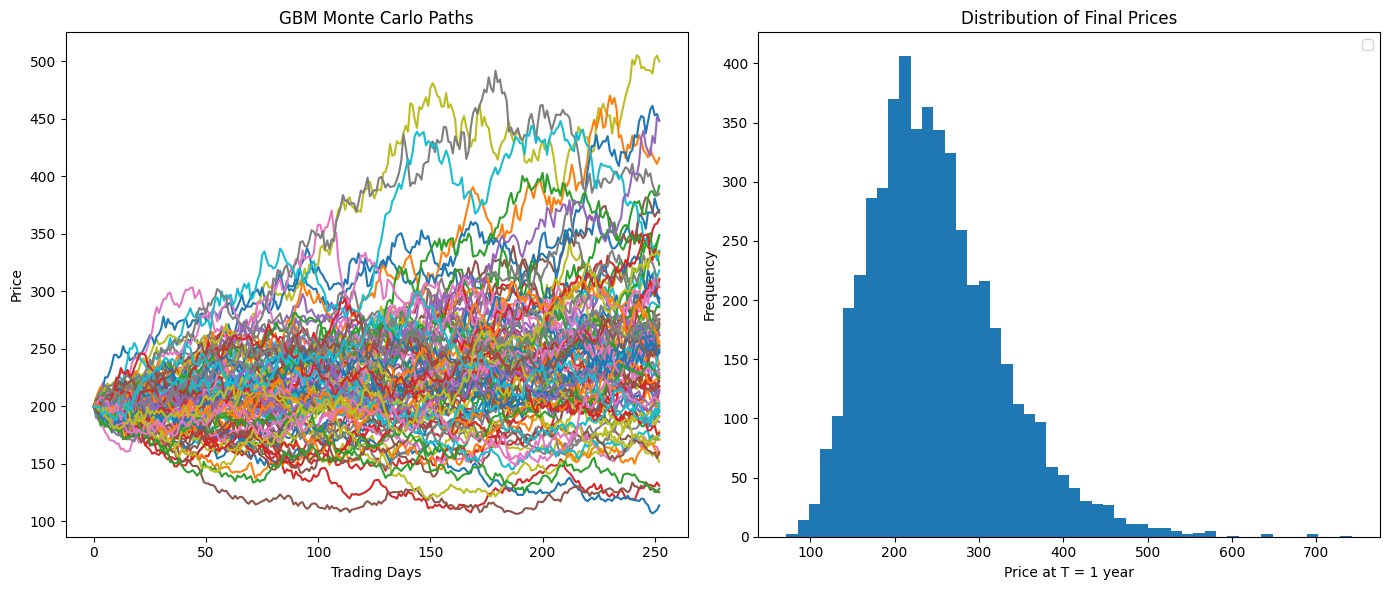

In [12]:
paths = simulate_paths(
    s0=200,
    params=params,
    n_paths=5000,
    years=1,
    random_seed=42,
)

# Terminal prices (last trading day)
terminal_prices = paths[-1]

# Create figure
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(14, 6),
)

# -------------------------
# Left: Simulated paths
# -------------------------
ax1.plot(paths[:, :100])
ax1.set_title("GBM Monte Carlo Paths")
ax1.set_xlabel("Trading Days")
ax1.set_ylabel("Price")

# -------------------------
# Right: Terminal distribution
# -------------------------
ax2.hist(
    terminal_prices,
    bins=50,
)



"""ax2.axvline(
    np.mean(terminal_prices),
    linestyle="--",
    label=f"Mean = {np.mean(terminal_prices):.2f}",
    )
    ax2.axvline(
    np.median(terminal_prices),
    linestyle=":",
    label=f"Median = {np.median(terminal_prices):.2f}",
)
"""


ax2.set_title("Distribution of Final Prices")
ax2.set_xlabel("Price at T = 1 year")
ax2.set_ylabel("Frequency")
ax2.legend()

plt.tight_layout()
plt.show()

In [5]:
paths = simulate_paths(
    s0=200,
    params=params,
    n_paths=5000,
    years=1,
    random_seed=42,
)

terminal_prices = paths[-1]

# Terminal log returns
log_returns = np.log(terminal_prices / 200)

# Theoretical values
theoretical_mean = (
    params.drift
    - 0.5 * params.volatility**2
)

theoretical_volatility = params.volatility

# Simulated values
simulated_mean = np.mean(log_returns)
simulated_volatility = np.std(log_returns)

print(
    f"Theoretical mean log-return: {theoretical_mean:.6f}"
)
print(
    f"Simulated mean log-return:   {simulated_mean:.6f}"
)

print()

print(
    f"Theoretical volatility:      {theoretical_volatility:.6f}"
)
print(
    f"Simulated volatility:        {simulated_volatility:.6f}"
)
estimated_sigma = np.std(log_returns)

estimated_mu = (
    np.mean(log_returns)
    + 0.5 * estimated_sigma**2
)

print(
    f"Real drift (mu):      {params.drift:.6f}"
)
print(
    f"Estimated drift:      {estimated_mu:.6f}"
)

print()

print(
    f"Real volatility:      {params.volatility:.6f}"
)
print(
    f"Estimated volatility: {estimated_sigma:.6f}"
)

Theoretical mean log-return: 0.178471
Simulated mean log-return:   0.171348

Theoretical volatility:      0.313150
Simulated volatility:        0.312487
Real drift (mu):      0.227503
Estimated drift:      0.220172

Real volatility:      0.313150
Estimated volatility: 0.312487


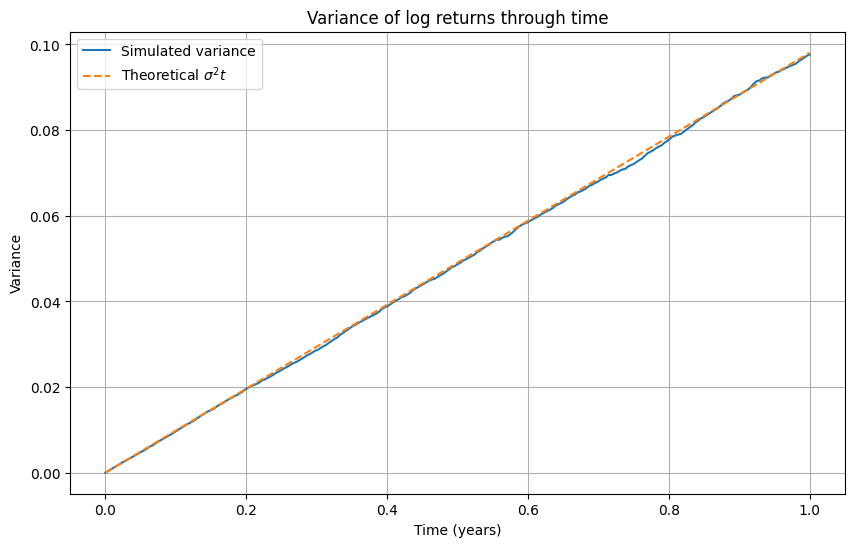

In [6]:

log_paths = np.log(paths / 200)

# variance across paths at each time
variances = np.var(log_paths, axis=1)

# time axis in years
n_steps = paths.shape[0] - 1
time = np.arange(n_steps + 1) / 252
theoretical_variance = params.volatility**2 * time
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    time,
    variances,
    label="Simulated variance",
)

plt.plot(
    time,
    theoretical_variance,
    "--",
    label=r"Theoretical $\sigma^2 t$",
)

plt.xlabel("Time (years)")
plt.ylabel("Variance")
plt.title("Variance of log returns through time")
plt.legend()
plt.grid(True)

plt.show()

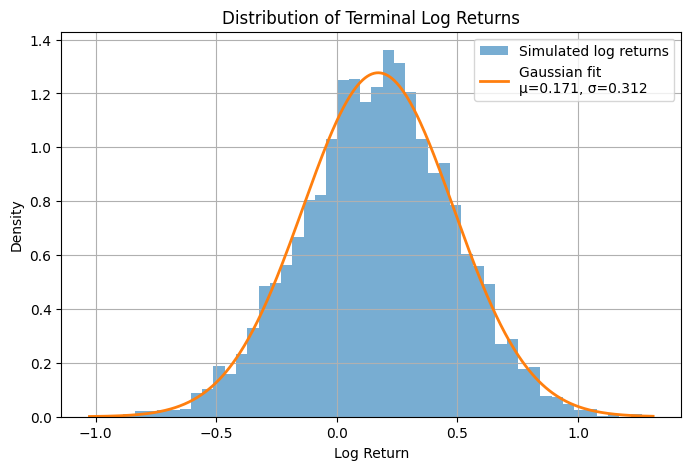

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

terminal_prices = paths[-1]

# Terminal log returns
log_returns = np.log(terminal_prices / 200)

# Fit Gaussian
mu = np.mean(log_returns)
sigma = np.std(log_returns)

# Histogram normalized to density
plt.figure(figsize=(8, 5))
plt.hist(
    log_returns,
    bins=50,
    density=True,
    alpha=0.6,
    label="Simulated log returns",
)

# Gaussian fit
x = np.linspace(
    log_returns.min(),
    log_returns.max(),
    500,
)

pdf = norm.pdf(x, mu, sigma)

plt.plot(
    x,
    pdf,
    linewidth=2,
    label=f"Gaussian fit\nμ={mu:.3f}, σ={sigma:.3f}",
)

plt.xlabel("Log Return")
plt.ylabel("Density")
plt.title("Distribution of Terminal Log Returns")
plt.legend()
plt.grid(True)

plt.show()

In [15]:
from scipy.stats import skew, kurtosis
historical_log_returns=returns
# Historical data
historical_skewness = skew(historical_log_returns)
historical_excess_kurtosis = kurtosis(
    historical_log_returns,
    fisher=True,  # excess kurtosis
)

print("Historical Data")
print(f"Skewness:         {historical_skewness.item():.4f}")
print(f"Excess Kurtosis:  {historical_excess_kurtosis.item():.4f}")

Historical Data
Skewness:         0.0210
Excess Kurtosis:  6.4340


In [16]:
# Daily simulated log returns
simulated_returns = np.diff(np.log(paths), axis=0)

# Flatten all paths into one sample
simulated_returns = simulated_returns.flatten()

simulated_skewness = skew(simulated_returns)
simulated_excess_kurtosis = kurtosis(
    simulated_returns,
    fisher=True,  # excess kurtosis
)

print("\nSimulated Data")
print(f"Skewness:         {simulated_skewness:.4f}")
print(f"Excess Kurtosis:  {simulated_excess_kurtosis:.4f}")


Simulated Data
Skewness:         -0.0017
Excess Kurtosis:  -0.0051
